# 1 Extracting Data

### 1.0 Imports

In [3]:
import pandas as pd
from fitparse import FitFile
from collections import Counter
from pathlib import Path
from datetime import datetime, timedelta
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# ============================================================
# Parameters
# ============================================================
first_date =  "2026-06-06"

LOCAL_OFFSET = pd.Timedelta(hours=2)

GARMIN_EPOCH = datetime(1989, 12, 31)

# ============================================================
# CHANGE WHEN ADDING NEW DAY
# ============================================================

dates = [
    "2026-06-03",
    "2026-06-04",
    "2026-06-05",
    "2026-06-06",
    "2026-06-07",
]

COGNITIVE_LOGS = {
    "2026-06-03": [
        ("09:14", "09:59"),
        ("11:00", "11:24"),
        ("11:43", "12:36"),
        ("13:53", "15:11"),
        ("16:17", "17:20"),
    ],
    "2026-06-04": [
        ("10:26", "11:12"),
        ("11:22", "11:30"),
        ("11:38", "12:50"),
        ("14:04", "15:24"),
        ("16:35", "16:57"),
        ("17:25", "17:45"),
        ("17:59", "18:34"),
    ],
    "2026-06-05": [
        ("10:12", "11:48"),
        ("12:22", "12:59"),
        ("14:24", "15:46"),
        ("16:23", "17:39"),
    ],
    "2026-06-06": [
        ("09:42", "10:56"),
        ("11:23", "12:50"),
        ("13:53", "14:49"),
        ("15:55", "17:11"),
    ],
    "2026-06-07": [
        ("16:24", "16:40"),
    ],
}

In [5]:
# ============================================================
# Select date and inspect WELLNESS files
# ============================================================
data_dir = Path(f"../data/{first_date}")
wellness_files = sorted(data_dir.glob("*_WELLNESS.fit"))
sleep_file = next(
    data_dir.glob("*_SLEEP_DATA.fit"),
    None
)

print(f"Found {len(wellness_files)} WELLNESS files\n")

summary = []

for file in wellness_files:
    fitfile = FitFile(str(file))

    stress_count = 0

    for _ in fitfile.get_messages("stress_level"):
        stress_count += 1

    summary.append({
        "file": file.name,
        "stress_records": stress_count
    })

summary_df = pd.DataFrame(summary)

display(summary_df)

Found 6 WELLNESS files



,file,stress_records
0,445843698586_WELLNESS.fit,28
1,445965680791_WELLNESS.fit,475
2,445966205557_WELLNESS.fit,6
3,446096285350_WELLNESS.fit,443
4,446152520161_WELLNESS.fit,228
5,446202624319_WELLNESS.fit,203


### 1.1 Stress

In [7]:
def extract_stress(
    wellness_files,
    curr_date,
    local_offset
):
    """
    Extract stress data from all WELLNESS files for one day.
    """

    all_rows = []

    for file in wellness_files:

        fitfile = FitFile(str(file))

        for msg in fitfile.get_messages("stress_level"):

            row = msg.get_values()

            all_rows.append({
                "source_file": file.name,
                "timestamp": row["stress_level_time"] + local_offset,
                "stress": row["stress_level_value"],
                "body_battery": row.get("body_battery")
            })

    stress_df = pd.DataFrame(all_rows)

    # Garmin missing value
    stress_df["stress"] = (
        stress_df["stress"]
        .replace(-1, pd.NA)
    )

    stress_df = (
        stress_df
        .sort_values("timestamp")
        .drop_duplicates(
            subset="timestamp",
            keep="last"
        )
        .reset_index(drop=True)
    )

    stress_df = stress_df[
        stress_df["timestamp"].dt.date
        == pd.to_datetime(curr_date).date()
    ].copy()

    return stress_df

In [8]:
stress_df = extract_stress(
    wellness_files,
    first_date,
    LOCAL_OFFSET
)

print("Rows:", len(stress_df))
print("Start:", stress_df["timestamp"].min())
print("End:", stress_df["timestamp"].max())

display(stress_df.head())
display(stress_df.tail())

Rows: 1382
Start: 2026-06-06 00:01:00
End: 2026-06-06 23:59:00


,source_file,timestamp,stress,body_battery
0,445843698586_WELLNESS.fit,2026-06-06 00:01:00,27,None
1,445843698586_WELLNESS.fit,2026-06-06 00:03:00,20,None
2,445843698586_WELLNESS.fit,2026-06-06 00:04:00,21,None
3,445843698586_WELLNESS.fit,2026-06-06 00:05:00,21,None
4,445843698586_WELLNESS.fit,2026-06-06 00:06:00,31,None


,source_file,timestamp,stress,body_battery
1377,446202624319_WELLNESS.fit,2026-06-06 23:55:00,11,None
1378,446202624319_WELLNESS.fit,2026-06-06 23:56:00,12,None
1379,446202624319_WELLNESS.fit,2026-06-06 23:57:00,9,None
1380,446202624319_WELLNESS.fit,2026-06-06 23:58:00,13,None
1381,446202624319_WELLNESS.fit,2026-06-06 23:59:00,14,None


### 1.2 Monitor Data

In [10]:
def extract_monitoring(
    wellness_files,
    curr_date
):
    """
    Extract heart-rate monitoring records from Garmin wellness FIT files.
    Reconstruct timestamps from timestamp + timestamp_16.
    """

    rows = []

    for file in wellness_files:

        fitfile = FitFile(str(file))

        last_timestamp = None
        last_timestamp16 = None

        for msg in fitfile.get_messages("monitoring"):

            row = msg.get_values()

            full_ts = row.get("timestamp")
            ts16 = row.get("timestamp_16")
            hr = row.get("heart_rate")

            # Full timestamp anchor
            if full_ts is not None:
                last_timestamp = full_ts + LOCAL_OFFSET

            timestamp = None

            if hr is not None:

                if full_ts is not None:

                    timestamp = full_ts + LOCAL_OFFSET

                elif (
                    ts16 is not None
                    and last_timestamp is not None
                    and last_timestamp16 is not None
                ):

                    delta = ts16 - last_timestamp16

                    # handle 16-bit rollover
                    if delta < 0:
                        delta += 65536

                    timestamp = (
                        last_timestamp
                        + timedelta(seconds=delta)
                    )

                if timestamp is not None:

                    rows.append({
                        "source_file": file.name,
                        "timestamp": timestamp,
                        "heart_rate": hr,
                    })

                    # advance reconstructed timeline
                    last_timestamp = timestamp

            # IMPORTANT:
            # update timestamp16 even when no HR exists
            if ts16 is not None:
                last_timestamp16 = ts16

    monitoring_df = pd.DataFrame(
        rows,
        columns=[
            "source_file",
            "timestamp",
            "heart_rate"
        ]
    )

    if monitoring_df.empty:
        return monitoring_df

    monitoring_df = (
        monitoring_df
        .sort_values("timestamp")
        .drop_duplicates(
            subset="timestamp",
            keep="last"
        )
        .reset_index(drop=True)
    )

    return monitoring_df

In [11]:
monitoring_df = extract_monitoring(
    wellness_files,
    first_date
)

print("Rows:", len(monitoring_df))
print("Start:", monitoring_df["timestamp"].min())
print("End:", monitoring_df["timestamp"].max())

monitoring_df.notna().sum().sort_values(ascending=False)

Rows: 1175
Start: 2026-06-06 00:02:00
End: 2026-06-07 00:00:00


source_file    1175
timestamp      1175
heart_rate     1175
dtype: int64

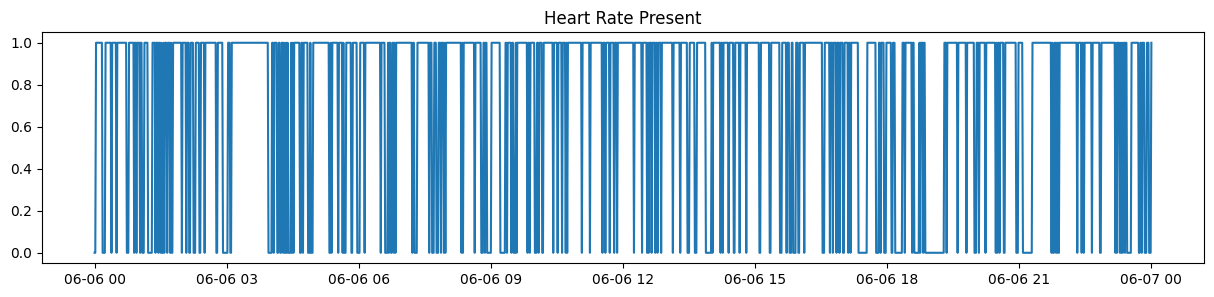

In [12]:
full_day = pd.date_range(
    monitoring_df["timestamp"].min().floor("D"),
    monitoring_df["timestamp"].max().ceil("D"),
    freq="1min"
)

availability = (
    monitoring_df
    .set_index("timestamp")
    .reindex(full_day)
    ["heart_rate"]
    .notna()
)

plt.figure(figsize=(15, 3))
plt.plot(availability.astype(int))
plt.title("Heart Rate Present")
plt.show()

### 1.3 Body Battery

In [14]:
def extract_body_battery(
    wellness_files,
    curr_date,
    local_offset
):
    """
    Extract body battery data from all WELLNESS files for one day.
    """

    all_rows = []

    for file in wellness_files:

        fitfile = FitFile(str(file))

        for msg in fitfile.get_messages("stress_level"):

            row = msg.get_values()

            all_rows.append({
                "source_file": file.name,
                "timestamp": row["stress_level_time"] + local_offset,
                "body_battery": row["unknown_3"]
            })

    body_battery_df = pd.DataFrame(all_rows)

    body_battery_df["body_battery"] = (
        body_battery_df["body_battery"]
        .replace(-1, pd.NA)
    )

    body_battery_df = (
        body_battery_df
        .sort_values("timestamp")
        .drop_duplicates(
            subset="timestamp",
            keep="last"
        )
        .reset_index(drop=True)
    )

    body_battery_df = body_battery_df[
        body_battery_df["timestamp"].dt.date
        == pd.to_datetime(curr_date).date()
    ].copy()

    return body_battery_df

In [15]:
body_battery_df = extract_body_battery(
    wellness_files,
    first_date,
    LOCAL_OFFSET
)

print("Rows:", len(body_battery_df))
print("Start:", body_battery_df["timestamp"].min())
print("End:", body_battery_df["timestamp"].max())

display(body_battery_df.head())
display(body_battery_df.tail())

Rows: 1382
Start: 2026-06-06 00:01:00
End: 2026-06-06 23:59:00


,source_file,timestamp,body_battery
0,445843698586_WELLNESS.fit,2026-06-06 00:01:00,22
1,445843698586_WELLNESS.fit,2026-06-06 00:03:00,22
2,445843698586_WELLNESS.fit,2026-06-06 00:04:00,22
3,445843698586_WELLNESS.fit,2026-06-06 00:05:00,22
4,445843698586_WELLNESS.fit,2026-06-06 00:06:00,22


,source_file,timestamp,body_battery
1377,446202624319_WELLNESS.fit,2026-06-06 23:55:00,36
1378,446202624319_WELLNESS.fit,2026-06-06 23:56:00,37
1379,446202624319_WELLNESS.fit,2026-06-06 23:57:00,37
1380,446202624319_WELLNESS.fit,2026-06-06 23:58:00,37
1381,446202624319_WELLNESS.fit,2026-06-06 23:59:00,37


### 1.4 Respirational Rate

In [17]:
def extract_respiration(
    wellness_files,
    curr_date,
    local_offset,
    garmin_epoch
):
    """
    Extract respiration data from all WELLNESS files for one day.
    """

    all_rows = []

    for file in wellness_files:

        fitfile = FitFile(str(file))

        for msg in fitfile.get_messages("unknown_297"):

            row = msg.get_values()

            all_rows.append({
                "source_file": file.name,
                "timestamp": (
                    garmin_epoch
                    + timedelta(seconds=row["unknown_253"])
                    + local_offset
                ),
                "respiration_rate": row["unknown_0"] / 100
            })

    respiration_df = pd.DataFrame(all_rows)

    respiration_df.loc[
        respiration_df["respiration_rate"] < 0,
        "respiration_rate"
    ] = pd.NA

    respiration_df = (
        respiration_df
        .sort_values("timestamp")
        .drop_duplicates(
            subset="timestamp",
            keep="last"
        )
        .reset_index(drop=True)
    )

    respiration_df = respiration_df[
        respiration_df["timestamp"].dt.date
        == pd.to_datetime(curr_date).date()
    ].copy()

    return respiration_df

In [18]:
respiration_df = extract_respiration(
    wellness_files,
    first_date,
    LOCAL_OFFSET,
    GARMIN_EPOCH
)

print("Rows:", len(respiration_df))
print("Start:", respiration_df["timestamp"].min())
print("End:", respiration_df["timestamp"].max())

display(respiration_df.head())
display(respiration_df.tail())

Rows: 1439
Start: 2026-06-06 00:01:00
End: 2026-06-06 23:59:00


,source_file,timestamp,respiration_rate
0,445843698586_WELLNESS.fit,2026-06-06 00:01:00,14.58
1,445843698586_WELLNESS.fit,2026-06-06 00:02:00,12.66
2,445843698586_WELLNESS.fit,2026-06-06 00:03:00,13.66
3,445843698586_WELLNESS.fit,2026-06-06 00:04:00,13.91
4,445843698586_WELLNESS.fit,2026-06-06 00:05:00,11.33


,source_file,timestamp,respiration_rate
1434,446202624319_WELLNESS.fit,2026-06-06 23:55:00,14.00
1435,446202624319_WELLNESS.fit,2026-06-06 23:56:00,14.16
1436,446202624319_WELLNESS.fit,2026-06-06 23:57:00,13.50
1437,446202624319_WELLNESS.fit,2026-06-06 23:58:00,14.08
1438,446202624319_WELLNESS.fit,2026-06-06 23:59:00,13.33


### 1.5 Event Logs - Activity Type

In [20]:
ACTIVITY_MAP = {
    0: "generic",
    1: "running",
    2: "cycling",
    6: "walking",
    8: "sedentary"
}

In [21]:
def extract_activity_events(
    wellness_files,
    GARMIN_EPOCH,
    LOCAL_OFFSET
):
    """
    Extract Garmin auto-detected activity events.

    Decodes:
        unknown_14 -> activity code
        unknown_15 -> start timestamp

    Returns:
        timestamp
        start_timestamp
        end_timestamp
        activity_code
        activity_type
        duration_min
    """

    ACTIVITY_MAP = {
        0: "generic",
        1: "running",
        2: "cycling",
        6: "walking",
        8: "sedentary"
    }

    rows = []

    for file in wellness_files:

        fitfile = FitFile(str(file))

        for msg in fitfile.get_messages("event"):

            row = msg.get_values()

            # Skip non-auto-activity markers
            if row.get("event") != 54:
                continue

            activity_code = row.get("unknown_14")
            duration_min = row.get("data")
            start_seconds = row.get("unknown_15")

            if (
                activity_code is None
                or duration_min is None
                or start_seconds is None
            ):
                continue

            start_timestamp = (
                GARMIN_EPOCH
                + timedelta(seconds=int(start_seconds))
                + LOCAL_OFFSET
            )

            end_timestamp = (
                start_timestamp
                + timedelta(minutes=int(duration_min))
            )

            rows.append({
                "source_file": file.name,
                "timestamp": row.get("timestamp"),

                "activity_code": activity_code,
                "activity_type": ACTIVITY_MAP.get(
                    activity_code,
                    "unknown"
                ),

                "duration_min": int(duration_min),

                "start_timestamp": start_timestamp,
                "end_timestamp": end_timestamp
            })

    events_df = (
        pd.DataFrame(rows)
        .sort_values("start_timestamp")
        .reset_index(drop=True)
    )

    return events_df

In [22]:
events_df = extract_activity_events(
    wellness_files,
    GARMIN_EPOCH,
    LOCAL_OFFSET
)

print("Rows:", len(events_df))

if len(events_df) > 0:
    print("Start:", events_df["start_timestamp"].min())
    print("End:", events_df["end_timestamp"].max())

display(events_df.head())
display(events_df.tail())

print(events_df["activity_type"].value_counts())

Rows: 253
Start: 2026-06-05 23:13:00
End: 2026-06-06 23:35:00


,source_file,timestamp,activity_code,activity_type,duration_min,start_timestamp,end_timestamp
0,445965680791_WELLNESS.fit,2026-06-06 00:46:00,8,sedentary,198,2026-06-05 23:13:00,2026-06-06 02:31:00
1,445965680791_WELLNESS.fit,2026-06-06 00:47:00,0,generic,1,2026-06-06 02:31:00,2026-06-06 02:32:00
2,445965680791_WELLNESS.fit,2026-06-06 01:59:00,8,sedentary,72,2026-06-06 02:32:00,2026-06-06 03:44:00
3,445965680791_WELLNESS.fit,2026-06-06 02:00:00,0,generic,1,2026-06-06 03:44:00,2026-06-06 03:45:00
4,445965680791_WELLNESS.fit,2026-06-06 04:23:00,8,sedentary,143,2026-06-06 03:45:00,2026-06-06 06:08:00


,source_file,timestamp,activity_code,activity_type,duration_min,start_timestamp,end_timestamp
248,446202624319_WELLNESS.fit,2026-06-06 21:24:00,0,generic,1,2026-06-06 23:08:00,2026-06-06 23:09:00
249,446202624319_WELLNESS.fit,2026-06-06 21:28:00,8,sedentary,4,2026-06-06 23:09:00,2026-06-06 23:13:00
250,446202624319_WELLNESS.fit,2026-06-06 21:30:00,0,generic,2,2026-06-06 23:13:00,2026-06-06 23:15:00
251,446202624319_WELLNESS.fit,2026-06-06 21:49:00,8,sedentary,19,2026-06-06 23:15:00,2026-06-06 23:34:00
252,446202624319_WELLNESS.fit,2026-06-06 21:50:00,0,generic,1,2026-06-06 23:34:00,2026-06-06 23:35:00


activity_type
generic      126
sedentary    123
cycling        2
running        1
walking        1
Name: count, dtype: int64


### 1.6 Sleep Data

In [24]:
def extract_sleep_levels(
    sleep_file,
    LOCAL_OFFSET
):
    """
    Extract sleep stage transitions and sleep
    start/stop times from SLEEP_DATA.fit.
    """

    sleep_map = {
        1: "awake",
        2: "light",
        3: "deep",
        4: "rem"
    }

    all_rows = []

    sleep_start = None
    sleep_stop = None

    fitfile = FitFile(str(sleep_file))

    # ========================================================
    # Sleep start / stop events
    # ========================================================

    for msg in fitfile.get_messages("event"):

        row = msg.get_values()

        if row.get("event") != 74:
            continue

        timestamp = (
            row["timestamp"]
            + LOCAL_OFFSET
        )

        if row.get("event_type") == "start":
            sleep_start = timestamp

        elif row.get("event_type") == "stop":
            sleep_stop = timestamp

    # ========================================================
    # Sleep stage transitions
    # ========================================================

    for msg in fitfile.get_messages("unknown_275"):

        row = msg.get_values()

        stage_code = row.get("unknown_0")
        garmin_epoch = row.get("unknown_253")

        if (
            stage_code is None
            or garmin_epoch is None
        ):
            continue

        timestamp = (
            GARMIN_EPOCH
            + pd.to_timedelta(
                garmin_epoch,
                unit="s"
            )
            + LOCAL_OFFSET
        )

        all_rows.append({
            "timestamp": timestamp,
            "sleep_level": sleep_map.get(
                stage_code,
                "unknown"
            )
        })

    sleep_df = pd.DataFrame(all_rows)

    if not sleep_df.empty:

        sleep_df = (
            sleep_df
            .sort_values("timestamp")
            .drop_duplicates(
                subset="timestamp",
                keep="last"
            )
            .reset_index(drop=True)
        )

    return (
        sleep_df,
        sleep_start,
        sleep_stop
    )

In [25]:
sleep_df, sleep_start, sleep_stop = (
    extract_sleep_levels(
        sleep_file,
        LOCAL_OFFSET
    )
)

print("Rows:", len(sleep_df))
print("Sleep start:", sleep_start)
print("Sleep stop :", sleep_stop)

display(sleep_df.head())
display(sleep_df.tail())

Rows: 23
Sleep start: 2026-06-05 23:26:41
Sleep stop : 2026-06-06 08:13:41


,timestamp,sleep_level
0,2026-06-05 23:30:41,light
1,2026-06-05 23:54:41,deep
2,2026-06-06 00:54:41,light
3,2026-06-06 01:04:41,deep
4,2026-06-06 01:32:41,light


,timestamp,sleep_level
18,2026-06-06 06:22:41,awake
19,2026-06-06 06:57:41,light
20,2026-06-06 07:07:41,rem
21,2026-06-06 07:08:41,awake
22,2026-06-06 08:13:41,light


### 1.7 Merging

In [27]:
def build_daily_df(
    stress_df,
    body_battery_df,
    respiration_df,
    monitoring_df,
    sleep_df,
    sleep_start,
    sleep_stop,
    events_df,
    curr_date
):
    """
    Merge all extracted Garmin data into a unified
    1-minute dataframe for one day.

    Activity labels come from events_df.
    Sleep stages come from SLEEP_DATA.fit.
    """

    # ========================================================
    # Ensure datetime dtype
    # ========================================================

    for df in [
        stress_df,
        body_battery_df,
        respiration_df,
        monitoring_df,
        sleep_df,
        events_df
    ]:
        if len(df) > 0:
            for col in df.columns:
                if "timestamp" in col:
                    df[col] = pd.to_datetime(df[col])

    target_date = pd.to_datetime(curr_date).date()

    # ========================================================
    # Filter physiological data
    # ========================================================

    stress_df = stress_df[
        stress_df["timestamp"].dt.date == target_date
    ].copy()

    body_battery_df = body_battery_df[
        body_battery_df["timestamp"].dt.date == target_date
    ].copy()

    respiration_df = respiration_df[
        respiration_df["timestamp"].dt.date == target_date
    ].copy()

    monitoring_df = monitoring_df[
        monitoring_df["timestamp"].dt.date == target_date
    ].copy()

    # ========================================================
    # Full timeline
    # ========================================================

    full_index = pd.date_range(
        start=pd.Timestamp(curr_date),
        periods=1440,
        freq="1min"
    )

    daily_df = pd.DataFrame(index=full_index)

    # ========================================================
    # Helper
    # ========================================================

    def prepare_minute_df(df, value_col):

        if len(df) == 0:
            return pd.DataFrame(columns=[value_col])

        temp = df.copy()

        temp["timestamp"] = (
            temp["timestamp"]
            .dt.floor("min")
        )

        return (
            temp.groupby("timestamp")[value_col]
            .first()
            .to_frame()
        )

    # ========================================================
    # Physiological features
    # ========================================================

    stress_min = prepare_minute_df(
        stress_df,
        "stress"
    )

    body_battery_min = prepare_minute_df(
        body_battery_df,
        "body_battery"
    )

    respiration_min = prepare_minute_df(
        respiration_df,
        "respiration_rate"
    )

    heart_rate_min = prepare_minute_df(
        monitoring_df,
        "heart_rate"
    )

    sleep_min = prepare_minute_df(
        sleep_df,
        "sleep_level"
    )

    # ========================================================
    # Merge physiological features
    # ========================================================

    for feature_df in [
        stress_min,
        body_battery_min,
        respiration_min,
        heart_rate_min
    ]:
        daily_df = daily_df.join(feature_df)

    # ========================================================
    # Sleep stages
    # ========================================================

    daily_df = daily_df.join(
        sleep_min,
        how="left"
    )

    daily_df["sleep_level"] = (
        daily_df["sleep_level"]
        .ffill()
    )

    daily_df["sleep_level"] = (
        daily_df["sleep_level"]
        .fillna("awake")
    )

    # before sleep starts -> awake

    if sleep_start is not None:

        daily_df.loc[
            daily_df.index < sleep_start,
            "sleep_level"
        ] = "awake"

    # after sleep ends -> awake

    if sleep_stop is not None:

        daily_df.loc[
            daily_df.index > sleep_stop,
            "sleep_level"
        ] = "awake"

    # ========================================================
    # Activity labels
    # ========================================================

    daily_df["activity_type"] = np.nan

    events_day = events_df[
        events_df["start_timestamp"].dt.date
        == target_date
    ].copy()

    for _, event in events_day.iterrows():

        mask = (
            (daily_df.index >= event["start_timestamp"])
            &
            (daily_df.index < event["end_timestamp"])
        )

        daily_df.loc[
            mask,
            "activity_type"
        ] = event["activity_type"]

    # ========================================================
    # Finalize
    # ========================================================

    daily_df.index.name = "timestamp"

    return daily_df.reset_index()

In [28]:
sleep_df, sleep_start, sleep_stop = (
    extract_sleep_levels(
        sleep_file,
        LOCAL_OFFSET
    )
)

print("sleep_start:", sleep_start)
print("sleep_stop :", sleep_stop)
print("rows:", len(sleep_df))

sleep_start: 2026-06-05 23:26:41
sleep_stop : 2026-06-06 08:13:41
rows: 23


In [29]:
daily_df = build_daily_df(
    stress_df,
    body_battery_df,
    respiration_df,
    monitoring_df,
    sleep_df,
    sleep_start,
    sleep_stop,
    events_df,
    first_date
)

print("Shape:", daily_df.shape)

print("\nMissing values:")
print(daily_df.isna().sum())

print("\nDate range:")
print(daily_df["timestamp"].min())
print(daily_df["timestamp"].max())

display(daily_df.head(20))

Shape: (1440, 7)

Missing values:
timestamp             0
stress              129
body_battery         58
respiration_rate    225
heart_rate          284
sleep_level           0
activity_type       176
dtype: int64

Date range:
2026-06-06 00:00:00
2026-06-06 23:59:00


C:\Users\gerib\AppData\Local\Temp\ipykernel_18228\3564982484.py:190: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'generic' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  daily_df.loc[


,timestamp,stress,body_battery,respiration_rate,heart_rate,sleep_level,activity_type
0,2026-06-06 00:00:00,NaN,NaN,NaN,NaN,awake,NaN
1,2026-06-06 00:01:00,27,22.0,14.58,NaN,awake,NaN
2,2026-06-06 00:02:00,NaN,NaN,12.66,61.0,awake,NaN
3,2026-06-06 00:03:00,20,22.0,13.66,62.0,awake,NaN
4,2026-06-06 00:04:00,21,22.0,13.91,64.0,awake,NaN
5,2026-06-06 00:05:00,21,22.0,11.33,65.0,awake,NaN
6,2026-06-06 00:06:00,31,22.0,13.83,69.0,awake,NaN
7,2026-06-06 00:07:00,23,23.0,15.50,64.0,awake,NaN
8,2026-06-06 00:08:00,37,23.0,14.41,73.0,awake,NaN
9,2026-06-06 00:09:00,20,23.0,15.41,64.0,awake,NaN


### 1.8 Cognitive Target

In [31]:
def add_cognitive_target(
    daily_df,
    curr_date,
    cognitive_logs
):
    """
    Add binary cognitive target.

    is_cognitive = 1 during logged cognitive sessions
    is_cognitive = 0 otherwise
    """

    daily_df = daily_df.copy()

    daily_df["timestamp"] = pd.to_datetime(
        daily_df["timestamp"]
    )

    daily_df["is_cognitive"] = 0

    sessions = cognitive_logs.get(
        curr_date,
        []
    )

    for start_str, end_str in sessions:

        start_dt = pd.Timestamp(
            f"{curr_date} {start_str}"
        )

        end_dt = pd.Timestamp(
            f"{curr_date} {end_str}"
        )

        mask = (
            (daily_df["timestamp"] >= start_dt)
            &
            (daily_df["timestamp"] < end_dt)
        )

        daily_df.loc[
            mask,
            "is_cognitive"
        ] = 1

    return daily_df

In [32]:
print(daily_df["timestamp"].head())
print(daily_df["timestamp"].tail())

0   2026-06-06 00:00:00
1   2026-06-06 00:01:00
2   2026-06-06 00:02:00
3   2026-06-06 00:03:00
4   2026-06-06 00:04:00
Name: timestamp, dtype: datetime64[ns]
1435   2026-06-06 23:55:00
1436   2026-06-06 23:56:00
1437   2026-06-06 23:57:00
1438   2026-06-06 23:58:00
1439   2026-06-06 23:59:00
Name: timestamp, dtype: datetime64[ns]


In [33]:
daily_df = add_cognitive_target(
    daily_df,
    first_date,
    COGNITIVE_LOGS
)

print(
    daily_df["is_cognitive"]
    .value_counts()
)

is_cognitive
0    1147
1     293
Name: count, dtype: int64


### 1.9 Save Function

In [35]:
def save_full_df(
    full_df,
    output_dir="../final_dfs",
    filename="full_df.csv"
):
    """
    Save the full extracted dataframe as one CSV file.
    """

    output_dir = Path(output_dir)

    output_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    output_file = output_dir / filename

    full_df.to_csv(
        output_file,
        index=False
    )

    print(f"Saved: {output_file}")

### 1.10 Data Extraction

In [37]:
def extract_day(
    curr_date,
    local_offset,
    garmin_epoch,
    cognitive_logs
):
    """
    Complete extraction pipeline for one day.

    Returns:
        daily_df
    """

    # ========================================================
    # Locate files
    # ========================================================

    data_dir = Path(f"../data/{curr_date}")

    wellness_files = sorted(
        data_dir.glob("*_WELLNESS.fit")
    )

    sleep_file = next(
        data_dir.glob("*_SLEEP_DATA.fit"),
        None
    )

    # ========================================================
    # Wellness-derived features
    # ========================================================

    stress_df = extract_stress(
        wellness_files,
        curr_date,
        local_offset
    )

    body_battery_df = extract_body_battery(
        wellness_files,
        curr_date,
        local_offset
    )

    respiration_df = extract_respiration(
        wellness_files,
        curr_date,
        local_offset,
        garmin_epoch
    )

    monitoring_df = extract_monitoring(
        wellness_files,
        curr_date
    )

    events_df = extract_activity_events(
        wellness_files,
        garmin_epoch,
        local_offset
    )

    # ========================================================
    # Sleep features
    # ========================================================

    if sleep_file is not None:

        (
            sleep_df,
            sleep_start,
            sleep_stop
        ) = extract_sleep_levels(
            sleep_file,
            local_offset
        )

    else:

        sleep_df = pd.DataFrame(
            columns=[
                "timestamp",
                "sleep_level"
            ]
        )

        sleep_start = None
        sleep_stop = None

    # ========================================================
    # Optional debug
    # ========================================================

    print(
        f"{curr_date} | "
        f"sleep rows={len(sleep_df)} | "
        f"start={sleep_start} | "
        f"stop={sleep_stop}"
    )

    # ========================================================
    # Build minute-level dataframe
    # ========================================================

    daily_df = build_daily_df(
        stress_df,
        body_battery_df,
        respiration_df,
        monitoring_df,
        sleep_df,
        sleep_start,
        sleep_stop,
        events_df,
        curr_date
    )

    # ========================================================
    # Add cognitive workload target
    # ========================================================

    daily_df = add_cognitive_target(
        daily_df,
        curr_date,
        cognitive_logs
    )

    return daily_df

### 1.11 Extracting multiple days at once

In [39]:
# ============================================================
# Process all dates into one full dataframe
# ============================================================

daily_dfs = []

for curr_date in dates:

    print(f"\nProcessing {curr_date}")

    day_df = extract_day(
        curr_date,
        LOCAL_OFFSET,
        GARMIN_EPOCH,
        COGNITIVE_LOGS
    )

    daily_dfs.append(day_df)


# ============================================================
# Combine all days
# ============================================================

full_df = pd.concat(
    daily_dfs,
    ignore_index=True
)

# ============================================================
# Save CSV
# ============================================================

save_full_df(
    full_df,
    output_dir="../final_dfs",
    filename="full_df.csv"
)

# ============================================================
# Final checks
# ============================================================

print("\nFull dataframe shape:")
print(full_df.shape)

print("\nFull dataframe missing values:")
print(full_df.isna().sum())

print("\nSleep distribution:")
print(
    full_df["sleep_level"]
    .value_counts(dropna=False)
)

display(full_df.head())
display(full_df.tail())


Processing 2026-06-03
2026-06-03 | sleep rows=18 | start=2026-06-03 01:38:41 | stop=2026-06-03 08:10:41

Processing 2026-06-04


C:\Users\gerib\AppData\Local\Temp\ipykernel_18228\3564982484.py:190: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'generic' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  daily_df.loc[


2026-06-04 | sleep rows=24 | start=2026-06-03 23:43:44 | stop=2026-06-04 08:27:44

Processing 2026-06-05


C:\Users\gerib\AppData\Local\Temp\ipykernel_18228\3564982484.py:190: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'generic' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  daily_df.loc[


2026-06-05 | sleep rows=34 | start=2026-06-04 23:20:58 | stop=2026-06-05 09:08:58

Processing 2026-06-06


...

C:\Users\gerib\AppData\Local\Temp\ipykernel_18228\3564982484.py:190: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'generic' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  daily_df.loc[


2026-06-07 | sleep rows=33 | start=2026-06-06 23:22:41 | stop=2026-06-07 09:01:41
Saved: ..\final_dfs\full_df.csv

Full dataframe shape:
(7200, 8)

Full dataframe missing values:
timestamp              0
stress               842
body_battery         366
respiration_rate    1477
heart_rate          1415
sleep_level            0
activity_type        549
is_cognitive           0
dtype: int64

Sleep distribution:
sleep_level
awake    5638
light     643
deep      515
rem       404
Name: count, dtype: int64


C:\Users\gerib\AppData\Local\Temp\ipykernel_18228\3564982484.py:190: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'generic' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  daily_df.loc[


,timestamp,stress,body_battery,respiration_rate,heart_rate,sleep_level,activity_type,is_cognitive
0,2026-06-03 00:00:00,NaN,NaN,NaN,NaN,awake,NaN,0
1,2026-06-03 00:01:00,12,32.0,13.58,NaN,awake,NaN,0
2,2026-06-03 00:02:00,20,32.0,15.36,64.0,awake,NaN,0
3,2026-06-03 00:03:00,NaN,NaN,14.91,74.0,awake,generic,0
4,2026-06-03 00:04:00,22,32.0,16.58,64.0,awake,sedentary,0


,timestamp,stress,body_battery,respiration_rate,heart_rate,sleep_level,activity_type,is_cognitive
7195,2026-06-07 23:55:00,5,30.0,14.83,NaN,awake,NaN,0
7196,2026-06-07 23:56:00,4,30.0,14.50,52.0,awake,NaN,0
7197,2026-06-07 23:57:00,6,30.0,14.83,NaN,awake,NaN,0
7198,2026-06-07 23:58:00,6,30.0,14.75,53.0,awake,NaN,0
7199,2026-06-07 23:59:00,7,30.0,15.33,NaN,awake,NaN,0


# 2 EDA

In [41]:
def check_day(
    full_df,
    check_date
):
    """
    Inspect one day from the final dataframe.
    """

    print("=" * 60)
    print(f"DATE: {check_date}")
    print("=" * 60)

    day_df = full_df[
        full_df["timestamp"].dt.date
        == pd.to_datetime(check_date).date()
    ].copy()

    print("\nShape:")
    print(day_df.shape)

    print("\nMissing values:")
    print(day_df.isna().sum())

    print("\nCognitive distribution:")
    print(
        day_df["is_cognitive"]
        .value_counts(dropna=False)
    )

    print("\nSleep distribution:")
    print(
        day_df["sleep_level"]
        .value_counts(dropna=False)
    )

    display(day_df.head())
    display(day_df.tail())

    return day_df

In [42]:
all_dates = (
    full_df["timestamp"]
    .dt.date
    .astype(str)
    .unique()
)

for curr_date in all_dates:

    check_day(
        full_df,
        curr_date
    )

DATE: 2026-06-03

Shape:
(1440, 8)

Missing values:
timestamp             0
stress              221
body_battery         80
respiration_rate    307
heart_rate          264
sleep_level           0
activity_type        32
is_cognitive          0
dtype: int64

Cognitive distribution:
is_cognitive
0    1177
1     263
Name: count, dtype: int64

Sleep distribution:
sleep_level
awake    1185
light      95
rem        82
deep       78
Name: count, dtype: int64


,timestamp,stress,body_battery,respiration_rate,heart_rate,sleep_level,activity_type,is_cognitive
0,2026-06-03 00:00:00,NaN,NaN,NaN,NaN,awake,NaN,0
1,2026-06-03 00:01:00,12,32.0,13.58,NaN,awake,NaN,0
2,2026-06-03 00:02:00,20,32.0,15.36,64.0,awake,NaN,0
3,2026-06-03 00:03:00,NaN,NaN,14.91,74.0,awake,generic,0
4,2026-06-03 00:04:00,22,32.0,16.58,64.0,awake,sedentary,0


,timestamp,stress,body_battery,respiration_rate,heart_rate,sleep_level,activity_type,is_cognitive
1435,2026-06-03 23:55:00,17,21.0,14.91,NaN,awake,NaN,0
1436,2026-06-03 23:56:00,15,21.0,15.25,60.0,awake,NaN,0
1437,2026-06-03 23:57:00,13,23.0,15.00,59.0,awake,NaN,0
1438,2026-06-03 23:58:00,17,23.0,14.33,NaN,awake,NaN,0
1439,2026-06-03 23:59:00,24,23.0,15.16,58.0,awake,NaN,0


DATE: 2026-06-04

Shape:
(1440, 8)

Missing values:
timestamp             0
stress              144
body_battery         54
respiration_rate    273
heart_rate          278
sleep_level           0
activity_type        77
is_cognitive          0
dtype: int64

Cognitive distribution:
is_cognitive
0    1157
1     283
Name: count, dtype: int64

Sleep distribution:
sleep_level
awake    1120
light     137
deep      129
rem        54
Name: count, dtype: int64


,timestamp,stress,body_battery,respiration_rate,heart_rate,sleep_level,activity_type,is_cognitive
1440,2026-06-04 00:00:00,NaN,NaN,NaN,NaN,awake,NaN,0
1441,2026-06-04 00:01:00,NaN,NaN,15.00,61.0,awake,NaN,0
1442,2026-06-04 00:02:00,17,23.0,13.66,58.0,awake,NaN,0
1443,2026-06-04 00:03:00,20,23.0,14.16,60.0,awake,NaN,0
1444,2026-06-04 00:04:00,NaN,NaN,15.41,58.0,awake,NaN,0


...

,timestamp,stress,body_battery,respiration_rate,heart_rate,sleep_level,activity_type,is_cognitive
4320,2026-06-06 00:00:00,NaN,NaN,NaN,NaN,awake,NaN,0
4321,2026-06-06 00:01:00,27,22.0,14.58,NaN,awake,NaN,0
4322,2026-06-06 00:02:00,NaN,NaN,12.66,61.0,awake,NaN,0
4323,2026-06-06 00:03:00,20,22.0,13.66,62.0,awake,NaN,0
4324,2026-06-06 00:04:00,21,22.0,13.91,64.0,awake,NaN,0


,timestamp,stress,body_battery,respiration_rate,heart_rate,sleep_level,activity_type,is_cognitive
5755,2026-06-06 23:55:00,11,36.0,14.00,56.0,awake,NaN,0
5756,2026-06-06 23:56:00,12,37.0,14.16,57.0,awake,NaN,0
5757,2026-06-06 23:57:00,9,37.0,13.50,NaN,awake,NaN,0
5758,2026-06-06 23:58:00,13,37.0,14.08,NaN,awake,NaN,0
5759,2026-06-06 23:59:00,14,37.0,13.33,NaN,awake,NaN,0


DATE: 2026-06-07

Shape:
(1440, 8)

Missing values:
timestamp             0
stress              168
body_battery         95
respiration_rate    394
heart_rate          326
sleep_level           0
activity_type       191
is_cognitive          0
dtype: int64

Cognitive distribution:
is_cognitive
0    1424
1      16
Name: count, dtype: int64

Sleep distribution:
sleep_level
awake    1080
rem       154
light     153
deep       53
Name: count, dtype: int64


,timestamp,stress,body_battery,respiration_rate,heart_rate,sleep_level,activity_type,is_cognitive
5760,2026-06-07 00:00:00,NaN,NaN,NaN,NaN,awake,NaN,0
5761,2026-06-07 00:01:00,NaN,NaN,14.08,NaN,awake,NaN,0
5762,2026-06-07 00:02:00,15,37.0,14.50,NaN,awake,NaN,0
5763,2026-06-07 00:03:00,16,38.0,15.25,57.0,awake,NaN,0
5764,2026-06-07 00:04:00,15,38.0,15.16,NaN,awake,NaN,0


,timestamp,stress,body_battery,respiration_rate,heart_rate,sleep_level,activity_type,is_cognitive
7195,2026-06-07 23:55:00,5,30.0,14.83,NaN,awake,NaN,0
7196,2026-06-07 23:56:00,4,30.0,14.50,52.0,awake,NaN,0
7197,2026-06-07 23:57:00,6,30.0,14.83,NaN,awake,NaN,0
7198,2026-06-07 23:58:00,6,30.0,14.75,53.0,awake,NaN,0
7199,2026-06-07 23:59:00,7,30.0,15.33,NaN,awake,NaN,0


# 3 Preprocessing

### 3.1 Missing Values